# Notebook Guide

This notebook turns the unsupervised cluster assignments into a supervised prediction workflow.

The key idea is that discovered subtype labels become training targets for a classifier. That allows the project to score new samples later through the saved model objects, API, and dashboard.

While reading, focus on:
- how previous pipeline outputs are loaded,
- how the Random Forest model is trained and evaluated,
- how confidence and feature-importance plots are interpreted,
- and how the final saved artifacts support deployment.

---

# Phase 7: Prediction Pipeline
### Using src/predictor.py module

**What this notebook does:**
- Imports functions from `src/predictor.py`
- Trains a Random Forest classifier on discovered cluster labels
- Evaluates prediction accuracy
- Saves all 4 models (scaler, pca, kmeans, classifier)
- Tests prediction on a new simulated patient
- Makes the project ready for API deployment

---
## Cell 1: Import Libraries + predictor.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import yaml
import sys
import os

# Add project root so Python can find src/predictor.py
sys.path.append('..')

# Import ALL functions from src/predictor.py
from src.predictor import (
    train_subtype_predictor,
    save_all_models,
    predict_new_patient
)

plt.rcParams['figure.dpi'] = 120

print('All imports successful!')
print('\nFunctions loaded from src/predictor.py:')
print('  train_subtype_predictor() - trains Random Forest on cluster labels')
print('  save_all_models()         - saves all 4 models to disk')
print('  predict_new_patient()     - predicts subtype for new patient')

All imports successful!

Functions loaded from src/predictor.py:
  train_subtype_predictor() - trains Random Forest on cluster labels
  save_all_models()         - saves all 4 models to disk
  predict_new_patient()     - predicts subtype for new patient


---
## Cell 2: Load Config

In [2]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

os.makedirs('../results', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

print('Config loaded!')
print('Directories ready: results/ and models/')

Config loaded!
Directories ready: results/ and models/


---
## Cell 3: Load All Previous Phase Results
Load outputs from Phase 3, 4, and 5

In [3]:
# ── From Phase 4 ──────────────────────────────
X_pca  = np.load('../results/X_pca.npy')
X_umap = np.load('../results/X_umap.npy')

# ── From Phase 5 ──────────────────────────────
kmeans_labels = np.load('../results/kmeans_labels.npy')
final_labels  = np.load('../results/final_labels.npy')
kmeans        = joblib.load('../models/kmeans.pkl')

# ── From Phase 3 (preprocessor) ───────────────
scaler = joblib.load('../models/scaler.pkl')
pca    = joblib.load('../models/pca.pkl')

n_clusters = len(np.unique(kmeans_labels))

print('All previous results loaded!')
print(f'\n  X_pca shape:        {X_pca.shape}')
print(f'  kmeans_labels shape: {kmeans_labels.shape}')
print(f'  Number of subtypes:  {n_clusters}')
print(f'\n  Cluster sizes:')
for i in range(n_clusters):
    count = (kmeans_labels == i).sum()
    pct   = count / len(kmeans_labels) * 100
    print(f'    Subtype {i}: {count} cells ({pct:.1f}%)')

All previous results loaded!

  X_pca shape:        (23686, 50)
  kmeans_labels shape: (23686,)
  Number of subtypes:  2

  Cluster sizes:
    Subtype 0: 4476 cells (18.9%)
    Subtype 1: 19210 cells (81.1%)


---
## Cell 4: Train the Subtype Predictor
Calls `train_subtype_predictor()` from predictor.py

Trains Random Forest using X_pca as features
and kmeans_labels as targets.

⏳ **Takes 1-3 minutes**

Training Random Forest classifier...
Using X_pca as features, kmeans_labels as targets
80% training, 20% testing

Training subtype predictor...

Classification Report:
              precision    recall  f1-score   support

   Subtype 0       1.00      1.00      1.00       895
   Subtype 1       1.00      1.00      1.00      3843

    accuracy                           1.00      4738
   macro avg       1.00      1.00      1.00      4738
weighted avg       1.00      1.00      1.00      4738

Cross-validation accuracy: 0.999 ± 0.001


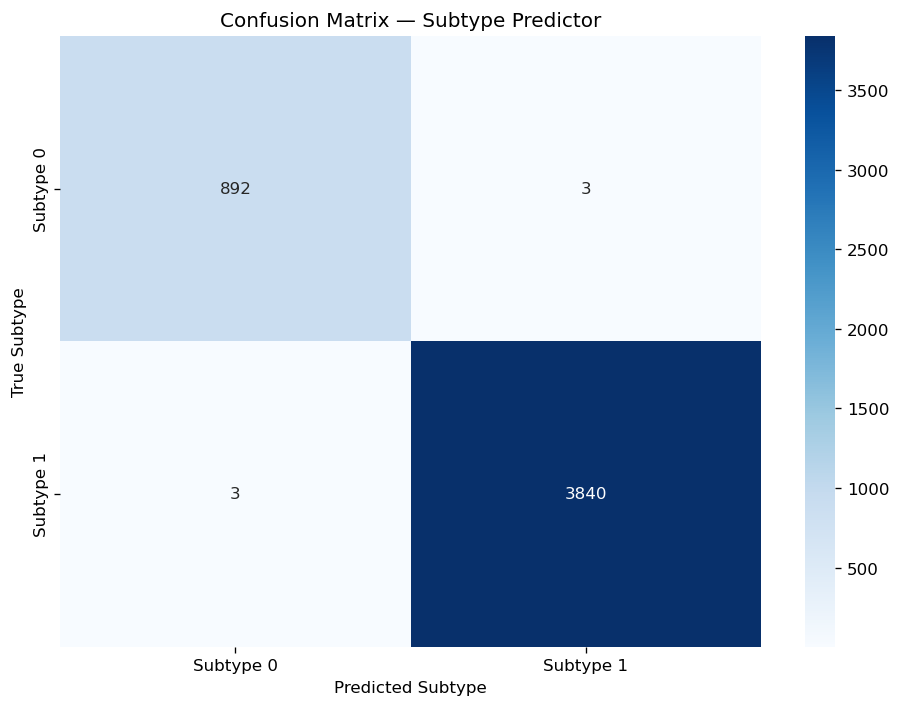


Classifier trained successfully!
Type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [4]:
# train_subtype_predictor() is defined in src/predictor.py
# Input:
#   X_pca         → 50 PCA components per cell (features)
#   kmeans_labels → cluster ID per cell (targets)
#   config        → project settings
#
# What happens inside:
#   1. Splits data 80% train / 20% test
#   2. Trains RandomForestClassifier(n_estimators=100)
#   3. Prints classification report
#   4. Prints cross-validation score
#   5. Plots confusion matrix
#
# Returns: trained classifier object

print('Training Random Forest classifier...')
print('Using X_pca as features, kmeans_labels as targets')
print('80% training, 20% testing')
print()

clf = train_subtype_predictor(X_pca, kmeans_labels, config)

print('\nClassifier trained successfully!')
print(f'Type: {type(clf)}')

---
## Cell 5: Save Confusion Matrix Plot
Save the confusion matrix that was generated during training

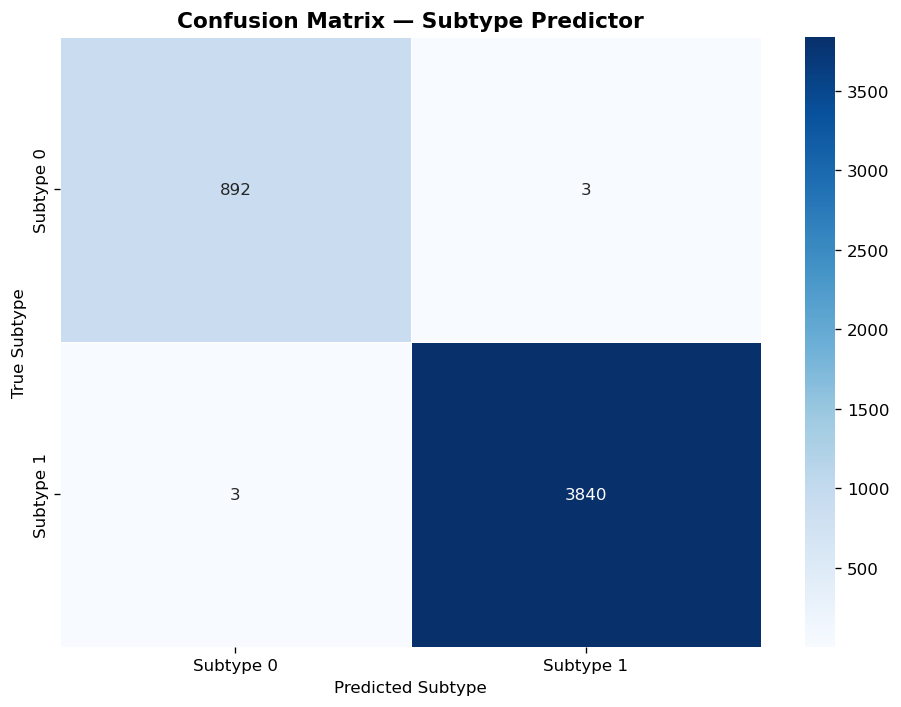

Confusion matrix saved to results/13_confusion_matrix.png

How to read:
  Diagonal numbers   = correct predictions (want these HIGH)
  Off-diagonal numbers = mistakes (want these LOW/ZERO)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Recreate train/test split with same random_state
# so we get the exact same split as during training
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, kmeans_labels,
    test_size=0.2,
    random_state=42,
    stratify=kmeans_labels
)

# Get predictions on test set
y_pred = clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
subtype_names = [f'Subtype {i}' for i in range(n_clusters)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=subtype_names,
    yticklabels=subtype_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — Subtype Predictor', fontsize=13, fontweight='bold')
plt.ylabel('True Subtype')
plt.xlabel('Predicted Subtype')
plt.tight_layout()
plt.savefig('../results/13_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Confusion matrix saved to results/13_confusion_matrix.png')
print('\nHow to read:')
print('  Diagonal numbers   = correct predictions (want these HIGH)')
print('  Off-diagonal numbers = mistakes (want these LOW/ZERO)')

---
## Cell 6: Feature Importance Plot
Which PCA components does the model rely on most?

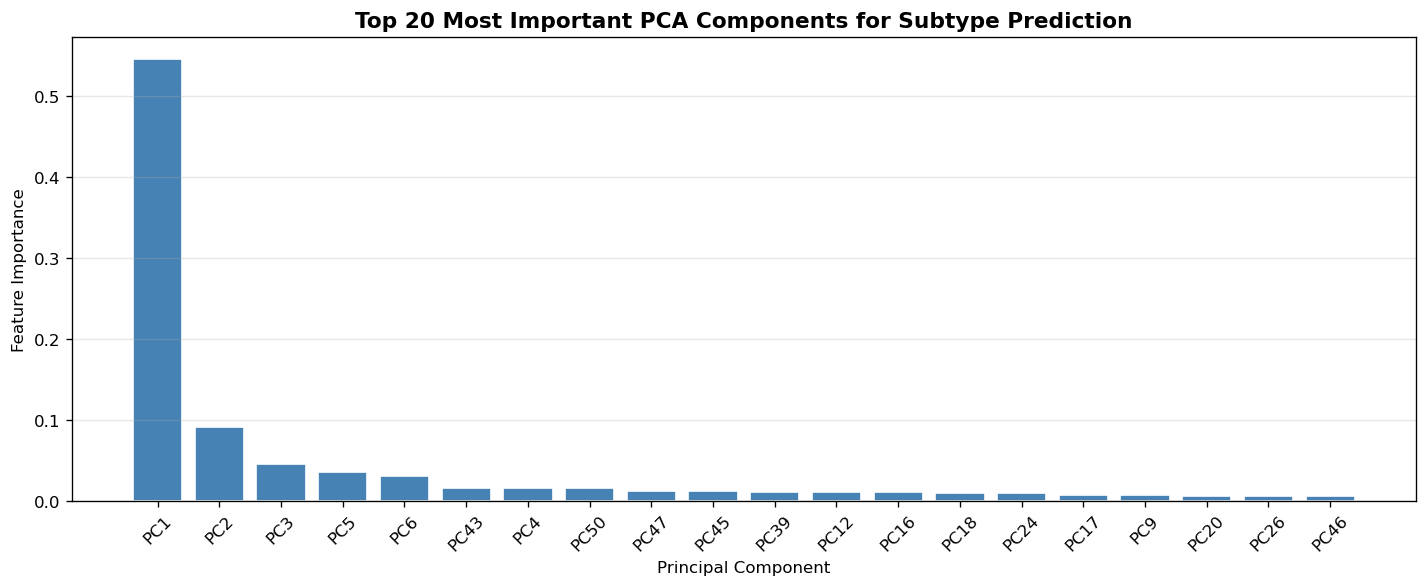

Feature importance plot saved to results/14_feature_importance.png

Top 5 most important components:
  PC1: 0.5454 (54.54%)
  PC2: 0.0909 (9.09%)
  PC3: 0.0449 (4.49%)
  PC5: 0.0354 (3.54%)
  PC6: 0.0305 (3.05%)


In [6]:
# Random Forest tells us which features it used most
# Here features = PCA components (PC1, PC2, ...PC50)

importances = clf.feature_importances_
pc_names    = [f'PC{i+1}' for i in range(len(importances))]

# Sort by importance
sorted_idx  = np.argsort(importances)[::-1]
top_n       = min(20, len(importances))

plt.figure(figsize=(12, 5))
plt.bar(
    range(top_n),
    importances[sorted_idx[:top_n]],
    color='steelblue',
    edgecolor='white'
)
plt.xticks(
    range(top_n),
    [pc_names[i] for i in sorted_idx[:top_n]],
    rotation=45
)
plt.title('Top 20 Most Important PCA Components for Subtype Prediction',
          fontsize=13, fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Feature Importance')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature importance plot saved to results/14_feature_importance.png')
print(f'\nTop 5 most important components:')
for i in range(5):
    idx = sorted_idx[i]
    print(f'  {pc_names[idx]}: {importances[idx]:.4f} ({importances[idx]*100:.2f}%)')

---
## Cell 7: Cross Validation Score
More reliable accuracy estimate using 5-fold cross validation

In [7]:
from sklearn.model_selection import cross_val_score

print('Running 5-fold cross validation...')
print('(Splits data 5 ways, tests on each split)')
print('This gives more reliable accuracy than single split...')

cv_scores = cross_val_score(
    clf, X_pca, kmeans_labels,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f'\nCross-validation results:')
print(f'  Fold 1: {cv_scores[0]:.4f} ({cv_scores[0]*100:.2f}%)')
print(f'  Fold 2: {cv_scores[1]:.4f} ({cv_scores[1]*100:.2f}%)')
print(f'  Fold 3: {cv_scores[2]:.4f} ({cv_scores[2]*100:.2f}%)')
print(f'  Fold 4: {cv_scores[3]:.4f} ({cv_scores[3]*100:.2f}%)')
print(f'  Fold 5: {cv_scores[4]:.4f} ({cv_scores[4]*100:.2f}%)')
print(f'  ─────────────────────────────────')
print(f'  Mean:   {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'  Std:    {cv_scores.std():.4f}  (± {cv_scores.std()*100:.2f}%)')

# Interpret the score
mean_acc = cv_scores.mean()
print(f'\nInterpretation:')
if mean_acc >= 0.90:
    print(f'  {mean_acc*100:.1f}% accuracy → Excellent! Model is very reliable.')
elif mean_acc >= 0.75:
    print(f'  {mean_acc*100:.1f}% accuracy → Good. Model is reasonably reliable.')
elif mean_acc >= 0.60:
    print(f'  {mean_acc*100:.1f}% accuracy → Fair. Clusters may have overlap.')
else:
    print(f'  {mean_acc*100:.1f}% accuracy → Low. Clusters are not well separated.')
    print(f'  Consider revisiting K selection in Phase 5.')

Running 5-fold cross validation...
(Splits data 5 ways, tests on each split)
This gives more reliable accuracy than single split...

Cross-validation results:
  Fold 1: 0.9985 (99.85%)
  Fold 2: 0.9992 (99.92%)
  Fold 3: 0.9981 (99.81%)
  Fold 4: 0.9996 (99.96%)
  Fold 5: 0.9994 (99.94%)
  ─────────────────────────────────
  Mean:   0.9989 (99.89%)
  Std:    0.0006  (± 0.06%)

Interpretation:
  99.9% accuracy → Excellent! Model is very reliable.


---
## Cell 8: Prediction Probability Plot
How confident is the model for each cell?

Prediction confidence statistics:
  Mean confidence:   98.8%
  Min confidence:    56.0%
  Max confidence:    100.0%
  Cells > 90% conf:  23272 (98.3%)
  Cells > 70% conf:  23669 (99.9%)
  Cells < 50% conf:  0 (uncertain cells)


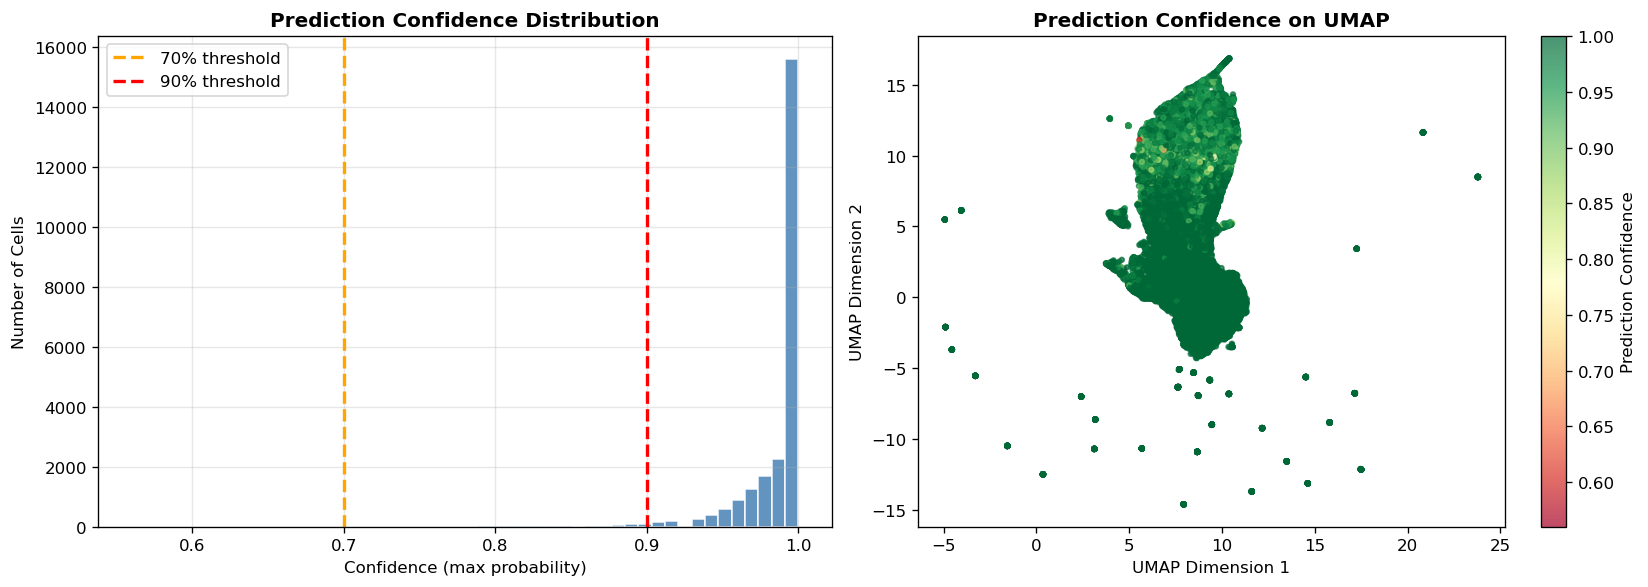


Confidence plots saved to results/15_prediction_confidence.png

UMAP interpretation:
  Green = high confidence (model is sure)
  Red   = low confidence (cell is near cluster boundary)


In [8]:
# Get prediction probabilities for ALL cells
all_probs      = clf.predict_proba(X_pca)
max_confidence = all_probs.max(axis=1)  # highest probability per cell

print(f'Prediction confidence statistics:')
print(f'  Mean confidence:   {max_confidence.mean()*100:.1f}%')
print(f'  Min confidence:    {max_confidence.min()*100:.1f}%')
print(f'  Max confidence:    {max_confidence.max()*100:.1f}%')
print(f'  Cells > 90% conf:  {(max_confidence > 0.9).sum()} ({(max_confidence > 0.9).mean()*100:.1f}%)')
print(f'  Cells > 70% conf:  {(max_confidence > 0.7).sum()} ({(max_confidence > 0.7).mean()*100:.1f}%)')
print(f'  Cells < 50% conf:  {(max_confidence < 0.5).sum()} (uncertain cells)')

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence
axes[0].hist(max_confidence, bins=50, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(x=0.7, color='orange', linestyle='--',
                linewidth=2, label='70% threshold')
axes[0].axvline(x=0.9, color='red', linestyle='--',
                linewidth=2, label='90% threshold')
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Confidence (max probability)')
axes[0].set_ylabel('Number of Cells')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# UMAP colored by confidence
scatter = axes[1].scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=max_confidence,
    cmap='RdYlGn',
    s=8, alpha=0.7
)
plt.colorbar(scatter, ax=axes[1], label='Prediction Confidence')
axes[1].set_title('Prediction Confidence on UMAP', fontweight='bold')
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_ylabel('UMAP Dimension 2')

plt.tight_layout()
plt.savefig('../results/15_prediction_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nConfidence plots saved to results/15_prediction_confidence.png')
print('\nUMAP interpretation:')
print('  Green = high confidence (model is sure)')
print('  Red   = low confidence (cell is near cluster boundary)')

---
## Cell 9: Save All Models
Calls `save_all_models()` from predictor.py

Saves all 4 models needed for the full prediction pipeline

In [9]:
# save_all_models() is defined in src/predictor.py
# Saves 4 files to models/ folder:
#   scaler.pkl     → preprocessing scaler (from Phase 3)
#   pca.pkl        → PCA reducer (from Phase 4)
#   kmeans.pkl     → clustering model (from Phase 5)
#   classifier.pkl → subtype predictor (trained in this phase)

save_all_models(
    scaler=scaler,
    pca=pca,
    kmeans=kmeans,
    clf=clf,
    save_dir='../models/'
)

# Verify all files saved correctly
print('\nVerifying saved files:')
model_files = ['scaler.pkl', 'pca.pkl', 'kmeans.pkl', 'classifier.pkl']
for fname in model_files:
    fpath = f'../models/{fname}'
    size  = os.path.getsize(fpath) / 1024
    print(f'  {fname:<20} {size:>8.1f} KB  ✓')

All models saved to ../models//
  scaler.pkl     — preprocessing scaler
  pca.pkl        — PCA reducer
  kmeans.pkl     — clustering model
  classifier.pkl — subtype predictor

Verifying saved files:
  scaler.pkl               87.6 KB  ✓
  pca.pkl                1481.5 KB  ✓
  kmeans.pkl               94.0 KB  ✓
  classifier.pkl         3192.0 KB  ✓


---
## Cell 10: Test predict_new_patient()
Calls `predict_new_patient()` from predictor.py

Simulates what happens when a new patient arrives

In [10]:
# predict_new_patient() is defined in src/predictor.py
# Takes raw gene expression values for ONE new patient
# Runs the full pipeline: log → scale → pca → predict
# Returns: (subtype_id, confidence)

# ── Test 1: Use a real cell from our dataset ──────────────
print('TEST 1: Predict subtype for an existing cell')
print('(Using Cell 0 from our dataset as a test)')

# Load the processed expression data
expr_df = pd.read_csv(
    f"../{config['data']['processed_expression']}",
    index_col=0
)

# Take the FIRST cell's gene expression values
test_cell_values = expr_df.iloc[0].values
true_label       = kmeans_labels[0]

# Predict using predictor.py function
predicted_subtype, confidence = predict_new_patient(
    test_cell_values,
    models_dir='../models/'
)

print(f'\n  True subtype:      Subtype {true_label}')
print(f'  Predicted subtype: Subtype {predicted_subtype}')
print(f'  Confidence:        {confidence*100:.1f}%')
print(f'  Correct:           {"✓ YES" if predicted_subtype == true_label else "✗ NO"}')

TEST 1: Predict subtype for an existing cell
(Using Cell 0 from our dataset as a test)

  True subtype:      Subtype 1
  Predicted subtype: Subtype 1
  Confidence:        100.0%
  Correct:           ✓ YES


---
## Cell 11: Test Multiple Cells

In [11]:
# Test on 10 random cells to see accuracy
print('TEST 2: Predict 10 random cells')
print('=' * 55)
print(f'{"Cell":>6} | {"True":>8} | {"Predicted":>10} | {"Confidence":>10} | {"Result":>8}')
print('-' * 55)

np.random.seed(42)
test_indices = np.random.choice(len(expr_df), 10, replace=False)
correct = 0

for idx in test_indices:
    cell_values = expr_df.iloc[idx].values
    true_label  = kmeans_labels[idx]

    pred_subtype, conf = predict_new_patient(
        cell_values,
        models_dir='../models/'
    )

    result = '✓' if pred_subtype == true_label else '✗'
    if pred_subtype == true_label:
        correct += 1

    print(f'{idx:>6} | {f"S{true_label}":>8} | {f"S{pred_subtype}":>10} | {conf*100:>9.1f}% | {result:>8}')

print('-' * 55)
print(f'Accuracy on 10 cells: {correct}/10 = {correct*10}%')

TEST 2: Predict 10 random cells
  Cell |     True |  Predicted | Confidence |   Result
-------------------------------------------------------
 21302 |       S1 |         S1 |     100.0% |        ✓
  9668 |       S1 |         S1 |     100.0% |        ✓
 18748 |       S1 |         S1 |     100.0% |        ✓
  6187 |       S1 |         S1 |     100.0% |        ✓
 21405 |       S0 |         S1 |      86.0% |        ✗
  4863 |       S1 |         S1 |     100.0% |        ✓
  5575 |       S1 |         S1 |     100.0% |        ✓
 20078 |       S1 |         S1 |     100.0% |        ✓
  3559 |       S1 |         S1 |     100.0% |        ✓
  6687 |       S1 |         S1 |      92.0% |        ✓
-------------------------------------------------------
Accuracy on 10 cells: 9/10 = 90%


---
## Cell 12: Simulate a Completely New Patient
What happens when someone with NO previous data comes in

In [12]:
# Simulate a completely new patient by slightly modifying
# an existing cell (adding small noise = simulating new individual)
print('TEST 3: Simulated completely new patient')
print()

# Take a real cell and add small noise to simulate new patient
base_cell   = expr_df.iloc[0].values.copy()
noise       = np.random.normal(0, 0.1, size=base_cell.shape)
new_patient = base_cell + noise
new_patient = np.clip(new_patient, 0, None)  # keep non-negative

pred_subtype, confidence = predict_new_patient(
    new_patient,
    models_dir='../models/'
)

# Get all probabilities for all subtypes
x = np.log1p(new_patient)
x = scaler.transform([x])
x = pca.transform(x)
all_probs = clf.predict_proba(x)[0]

print('Patient Gene Expression Report')
print('=' * 40)
print(f'Predicted Molecular Subtype: {pred_subtype}')
print(f'Overall Confidence:          {confidence*100:.1f}%')
print()
print('Probability per subtype:')
for i, prob in enumerate(all_probs):
    bar = '█' * int(prob * 40)
    print(f'  Subtype {i}: {prob*100:>5.1f}%  {bar}')
print('=' * 40)

TEST 3: Simulated completely new patient

Patient Gene Expression Report
Predicted Molecular Subtype: 1
Overall Confidence:          100.0%

Probability per subtype:
  Subtype 0:   0.0%  
  Subtype 1: 100.0%  ████████████████████████████████████████


---
## Cell 13: Save Final Results CSV

In [13]:
# Get predictions + confidence for ALL cells
all_predictions  = clf.predict(X_pca)
all_probabilities = clf.predict_proba(X_pca)
all_confidence   = all_probabilities.max(axis=1)

# Build comprehensive results dataframe
results_df = pd.DataFrame({
    'cell_index':        range(len(kmeans_labels)),
    'true_subtype':      kmeans_labels,
    'predicted_subtype': all_predictions,
    'confidence':        all_confidence,
    'correct':           kmeans_labels == all_predictions,
    'umap_x':            X_umap[:, 0],
    'umap_y':            X_umap[:, 1]
})

# Add probability columns for each subtype
for i in range(n_clusters):
    results_df[f'prob_subtype_{i}'] = all_probabilities[:, i]

results_df.to_csv('../results/prediction_results.csv', index=False)

overall_acc = (results_df['correct']).mean()
print('Final prediction results saved!')
print(f'\nOverall accuracy on all cells: {overall_acc*100:.2f}%')
print(f'Total cells:     {len(results_df)}')
print(f'Correct:         {results_df["correct"].sum()}')
print(f'Incorrect:       {(~results_df["correct"]).sum()}')
print(f'\nFile saved: results/prediction_results.csv')
print(f'Columns: {results_df.columns.tolist()}')

Final prediction results saved!

Overall accuracy on all cells: 99.97%
Total cells:     23686
Correct:         23680
Incorrect:       6

File saved: results/prediction_results.csv
Columns: ['cell_index', 'true_subtype', 'predicted_subtype', 'confidence', 'correct', 'umap_x', 'umap_y', 'prob_subtype_0', 'prob_subtype_1']


---
## Cell 14: Phase 7 Summary

In [14]:
print('=' * 55)
print('       PHASE 7 COMPLETE — SUMMARY')
print('=' * 55)
print(f'  Algorithm:           Random Forest (100 trees)')
print(f'  Training cells:      {int(len(kmeans_labels)*0.8)}')
print(f'  Test cells:          {int(len(kmeans_labels)*0.2)}')
print(f'  CV Accuracy:         {cv_scores.mean()*100:.2f}%')
print()
print('  Models saved to models/:')
print('    scaler.pkl         preprocessing scaler')
print('    pca.pkl            PCA reducer')
print('    kmeans.pkl         clustering model')
print('    classifier.pkl     subtype predictor')
print()
print('  Plots saved to results/:')
print('    13_confusion_matrix.png')
print('    14_feature_importance.png')
print('    15_prediction_confidence.png')
print()
print('  Data saved:')
print('    results/prediction_results.csv')
print()
print('  Next → Phase 8: FastAPI')
print('  Open api/app.py and run:')
print('  uvicorn api.app:app --reload')
print('=' * 55)

       PHASE 7 COMPLETE — SUMMARY
  Algorithm:           Random Forest (100 trees)
  Training cells:      18948
  Test cells:          4737
  CV Accuracy:         99.89%

  Models saved to models/:
    scaler.pkl         preprocessing scaler
    pca.pkl            PCA reducer
    kmeans.pkl         clustering model
    classifier.pkl     subtype predictor

  Plots saved to results/:
    13_confusion_matrix.png
    14_feature_importance.png
    15_prediction_confidence.png

  Data saved:
    results/prediction_results.csv

  Next → Phase 8: FastAPI
  Open api/app.py and run:
  uvicorn api.app:app --reload
